# CustomerLens — Business Segmentation & Strategic Insights
## Phase 10: Translating Behavioral Clusters into Explainable Commercial Opportunities

---

### 1. Title and Objective

The objective of **Phase 10** is to bridge unsupervised machine learning outputs (from K-Means clustering in Phase 9) with practical commercial decision-making. 

In this notebook, we:
1. Map mathematical cluster IDs $\{0, 1, 2, 3\}$ to intuitive, descriptive business personas:
   - **Cluster 3 $\rightarrow$ High-Value Engaged** (`action_category`: *Protect & Grow*)
   - **Cluster 2 $\rightarrow$ Established Valuable** (`action_category`: *Nurture*)
   - **Cluster 0 $\rightarrow$ Recent Developing** (`action_category`: *Develop*)
   - **Cluster 1 $\rightarrow$ Low-Engagement / Reactivation** (`action_category`: *Reactivate*)
2. Quantify the extreme revenue disparity across customer cohorts (Pareto concentration).
3. Characterize the empirical RFM attributes of each customer group using ground-truth data.
4. Formulate testable, hypothesis-driven marketing and retention opportunities with measurable KPIs and downside guardrails.
5. Emphasize empirical rigor: avoiding unsupported demographic assumptions, fake categories, or unsubstantiated churn and ROI claims.


### 2. Core Business Questions Addressed

This analytical layer addresses five fundamental commercial questions:

1. **Revenue Concentration:** What fraction of the business's £8.89M turnover is generated by top-tier commercial accounts versus one-off retail shoppers?
2. **Behavioral Differentiation:** How do customer purchase frequency, recency, and monetary baskets vary across the four behavioral cohorts?
3. **Operational Prioritization:** How should customer relationship management (CRM) and sales resources be allocated across segments?
4. **Growth & Conversion Levers:** What specific interventions could accelerate recent first-time buyers into repeat spenders?
5. **Reactivation Viability:** How should dormant accounts be approached without incurring negative marketing ROI?


In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root is accessible
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.segmentation import (
    load_cluster_profiles,
    load_customer_clusters,
    build_segment_summary,
    assign_business_segments,
)
from src.insights import (
    calculate_segment_contribution,
    build_opportunity_table,
    generate_segment_insights,
)

# Plotting aesthetics
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10
plt.rcParams["figure.titlesize"] = 12
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10

print("Environment initialized successfully.")


Environment initialized successfully.


In [2]:
# Load verified cluster profiles and build segment summary
PROFILES_PATH = PROJECT_ROOT / "data" / "processed" / "cluster_profiles.csv"
CLUSTERS_PATH = PROJECT_ROOT / "data" / "processed" / "customer_clusters.csv"

profiles_df = load_cluster_profiles(PROFILES_PATH)
segment_summary_df = build_segment_summary(profiles_df)
summary_with_contrib = calculate_segment_contribution(segment_summary_df)

print(f"Loaded {len(segment_summary_df)} segments from verified cluster profiles.")
summary_with_contrib[[
    "cluster_id", "business_segment", "action_category", "customer_count",
    "customer_percentage", "total_revenue", "revenue_percentage", "revenue_concentration_ratio"
]]


Loaded 4 segments from verified cluster profiles.


,cluster_id,business_segment,action_category,customer_count,customer_percentage,total_revenue,revenue_percentage,revenue_concentration_ratio
0,0,Recent Developing,Develop,834,19.23,465608.17,5.24,0.27
1,1,Low-Engagement / Reactivation,Reactivate,1618,37.30,547770.00,6.16,0.17
2,2,Established Valuable,Nurture,1170,26.97,2092321.70,23.54,0.87
3,3,High-Value Engaged,Protect & Grow,716,16.51,5781509.02,65.05,3.94


In [3]:
# Load customer-level dataset with assigned business segments
customer_clusters_df = load_customer_clusters(CLUSTERS_PATH)
customer_segments_df = assign_business_segments(customer_clusters_df)

print(f"Loaded {len(customer_segments_df):,} customer records.")
print(f"Unique segments: {customer_segments_df['business_segment'].nunique()}")
print(f"Nulls in business_segment: {customer_segments_df['business_segment'].isnull().sum()}")

customer_segments_df[[
    "customerid", "business_segment", "action_category", "recency", "frequency", "monetary", "RFM_score"
]].head(10)


Loaded 4,338 customer records.
Unique segments: 4
Nulls in business_segment: 0


,customerid,business_segment,action_category,recency,frequency,monetary,RFM_score
0,14646,High-Value Engaged,Protect & Grow,2,73,280206.02,545
1,18102,High-Value Engaged,Protect & Grow,1,60,259657.30,545
2,17450,High-Value Engaged,Protect & Grow,8,46,194390.79,545
3,16446,High-Value Engaged,Protect & Grow,1,2,168472.50,515
4,14911,High-Value Engaged,Protect & Grow,1,201,143711.17,545
5,12415,High-Value Engaged,Protect & Grow,24,21,124914.53,445
6,14156,High-Value Engaged,Protect & Grow,10,55,117210.08,545
7,17511,High-Value Engaged,Protect & Grow,3,31,91062.38,545
8,16029,High-Value Engaged,Protect & Grow,39,63,80850.84,345
9,12346,Established Valuable,Nurture,326,1,77183.60,115


### 6. Segment Overview & Action Categories

Each customer cluster is mapped to a descriptive business segment and an operational action category:

- **Cluster 3: High-Value Engaged (`Protect & Grow`):**
  - High-touch relationship management, priority service, and contract stability.
- **Cluster 2: Established Valuable (`Nurture`):**
  - Order frequency acceleration, basket threshold incentives, and cross-category cross-selling.
- **Cluster 0: Recent Developing (`Develop`):**
  - Automated post-purchase onboarding, second-order nudges, and product discovery.
- **Cluster 1: Low-Engagement / Reactivation (`Reactivate`):**
  - Low-cost digital win-back outreach, clearance promotions, and email preference surveys.


C:\Users\divya\AppData\Local\Temp\ipykernel_17160\2478692876.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\divya\AppData\Local\Temp\ipykernel_17160\2478692876.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha="right")
C:\Users\divya\AppData\Local\Temp\ipykernel_17160\2478692876.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\divya\AppData\Local\Temp\ipykernel_17160\2478692876.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after

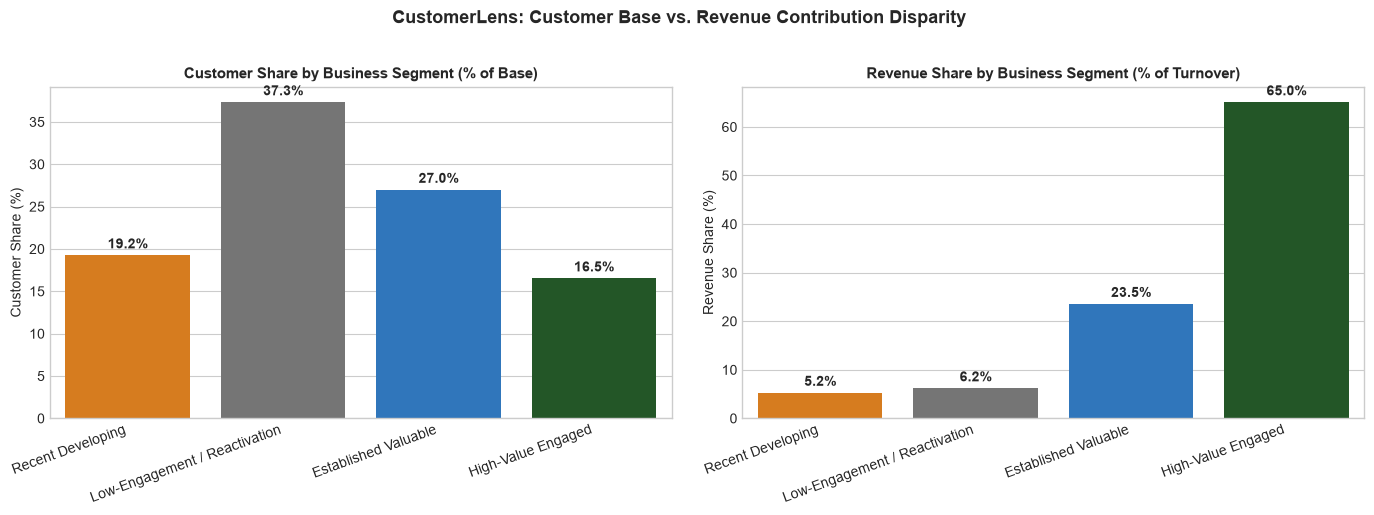

In [4]:
# Visualize Customer Share vs. Revenue Share Disparity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {
    "High-Value Engaged": "#1b5e20",
    "Established Valuable": "#1976d2",
    "Recent Developing": "#f57c00",
    "Low-Engagement / Reactivation": "#757575",
}

# 1. Customer Count Share
sns.barplot(
    data=summary_with_contrib,
    x="business_segment",
    y="customer_percentage",
    palette=palette,
    ax=axes[0]
)
axes[0].set_title("Customer Share by Business Segment (% of Base)", fontweight="bold")
axes[0].set_ylabel("Customer Share (%)")
axes[0].set_xlabel("")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha="right")
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha="center", va="bottom", xytext=(0, 3), textcoords="offset points", fontweight="bold")

# 2. Revenue Share
sns.barplot(
    data=summary_with_contrib,
    x="business_segment",
    y="revenue_percentage",
    palette=palette,
    ax=axes[1]
)
axes[1].set_title("Revenue Share by Business Segment (% of Turnover)", fontweight="bold")
axes[1].set_ylabel("Revenue Share (%)")
axes[1].set_xlabel("")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha="right")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha="center", va="bottom", xytext=(0, 3), textcoords="offset points", fontweight="bold")

plt.suptitle("CustomerLens: Customer Base vs. Revenue Contribution Disparity", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


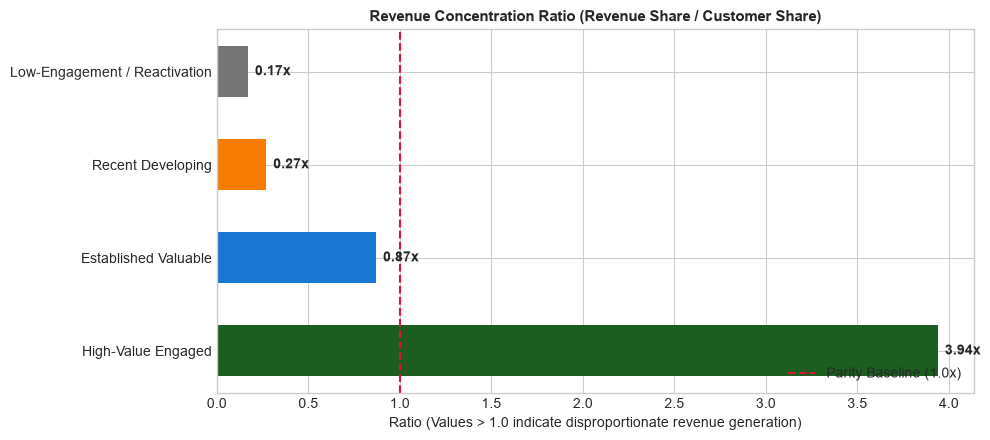

In [5]:
# Revenue Concentration Ratio: (% Revenue / % Customers)
fig, ax = plt.subplots(figsize=(10, 4.5))

sorted_contrib = summary_with_contrib.sort_values(by="revenue_concentration_ratio", ascending=False)
bars = ax.barh(
    sorted_contrib["business_segment"],
    sorted_contrib["revenue_concentration_ratio"],
    color=[palette[s] for s in sorted_contrib["business_segment"]],
    height=0.55
)
ax.axvline(1.0, color="crimson", linestyle="--", linewidth=1.5, label="Parity Baseline (1.0x)")

for bar in bars:
    width = bar.get_width()
    ax.annotate(f"{width:.2f}x",
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(5, 0), textcoords="offset points",
                ha="left", va="center", fontweight="bold", fontsize=10)

ax.set_title("Revenue Concentration Ratio (Revenue Share / Customer Share)", fontweight="bold")
ax.set_xlabel("Ratio (Values > 1.0 indicate disproportionate revenue generation)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


C:\Users\divya\AppData\Local\Temp\ipykernel_17160\1724541965.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_with_contrib, x="business_segment", y="median_recency", palette=palette, ax=axes[0])
C:\Users\divya\AppData\Local\Temp\ipykernel_17160\1724541965.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=25, ha="right")
C:\Users\divya\AppData\Local\Temp\ipykernel_17160\1724541965.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_with_contrib, x="business_segment", y="median_frequ

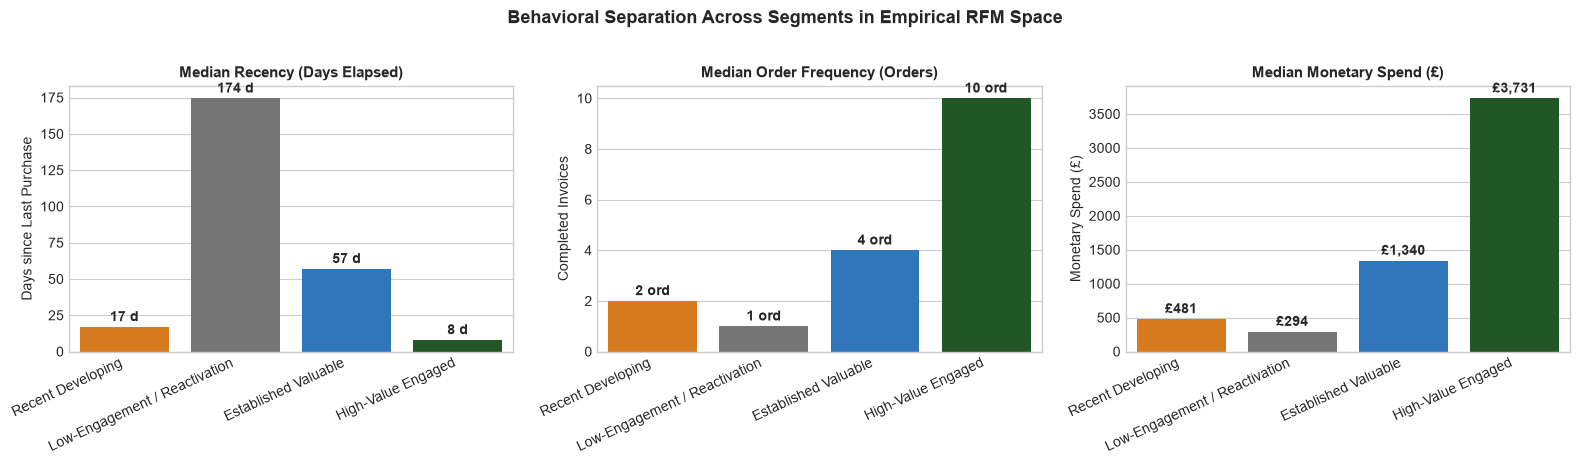

In [6]:
# Compare RFM Medians across Business Segments
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Median Recency (Lower is better)
sns.barplot(data=summary_with_contrib, x="business_segment", y="median_recency", palette=palette, ax=axes[0])
axes[0].set_title("Median Recency (Days Elapsed)", fontweight="bold")
axes[0].set_ylabel("Days since Last Purchase")
axes[0].set_xlabel("")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=25, ha="right")
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.0f} d", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha="center", va="bottom", xytext=(0, 2), textcoords="offset points", fontweight="bold")

# 2. Median Frequency (Higher is better)
sns.barplot(data=summary_with_contrib, x="business_segment", y="median_frequency", palette=palette, ax=axes[1])
axes[1].set_title("Median Order Frequency (Orders)", fontweight="bold")
axes[1].set_ylabel("Completed Invoices")
axes[1].set_xlabel("")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=25, ha="right")
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.0f} ord", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha="center", va="bottom", xytext=(0, 2), textcoords="offset points", fontweight="bold")

# 3. Median Monetary (Higher is better)
sns.barplot(data=summary_with_contrib, x="business_segment", y="median_monetary", palette=palette, ax=axes[2])
axes[2].set_title("Median Monetary Spend (£)", fontweight="bold")
axes[2].set_ylabel("Monetary Spend (£)")
axes[2].set_xlabel("")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=25, ha="right")
for p in axes[2].patches:
    axes[2].annotate(f"£{p.get_height():,.0f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha="center", va="bottom", xytext=(0, 2), textcoords="offset points", fontweight="bold")

plt.suptitle("Behavioral Separation Across Segments in Empirical RFM Space", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### 10. Segment Interpretation & Deep Dive

#### 1. High-Value Engaged (Cluster 3) — The Commercial Engine
- **Volume & Revenue:** 716 customers (16.51% of accounts) generating **£5,781,509.02 (65.05% of turnover)**.
- **Profile:** Median recency 8.0 days, median frequency 10.0 orders, median spend £3,730.61 (mean spend £8,074.73).
- **Interpretation:** Major wholesale retail distributors, commercial accounts, and high-frequency repeat institutional buyers. Highly vulnerable to churn; losing even a fraction of these accounts materially impacts enterprise revenue.

#### 2. Established Valuable (Cluster 2) — The Dependable Core
- **Volume & Revenue:** 1,170 customers (26.97% of accounts) generating **£2,092,321.70 (23.54% of turnover)**.
- **Profile:** Median recency 57.0 days, median frequency 4.0 orders, median spend £1,340.08.
- **Interpretation:** Predictable mid-market repeat purchasers who replenish quarterly or semi-monthly. High potential to graduate into top-tier status through basket expansion incentives.

#### 3. Recent Developing (Cluster 0) — The Growth Pipeline
- **Volume & Revenue:** 834 customers (19.23% of accounts) generating **£465,608.17 (5.24% of turnover)**.
- **Profile:** Median recency 17.0 days, median frequency 2.0 orders, median spend £481.03.
- **Interpretation:** New buyers acquired in the last 30–60 days who are currently engaged. The critical operational window is active now to secure the second and third orders.

#### 4. Low-Engagement / Reactivation (Cluster 1) — The Inactive Long Tail
- **Volume & Revenue:** 1,618 customers (37.30% of accounts) generating **£547,770.00 (6.16% of turnover)**.
- **Profile:** Median recency 174.5 days, median frequency 1.0 order, median spend £293.78.
- **Interpretation:** Primarily single-order gift buyers or one-off shoppers who purchased months ago and have not returned. Low-touch, automated communication is mandatory to prevent negative marketing ROI.


In [7]:
# Load structured marketing opportunities and experimentation framework
opportunities_df = build_opportunity_table(segment_summary_df)

pd.set_option("display.max_colwidth", None)
opportunities_df[[
    "business_segment", "action_category", "recommended_action", "measurement_metric", "caveat"
]]


,business_segment,action_category,recommended_action,measurement_metric,caveat
0,Recent Developing,Develop,"Deploy automated post-purchase email onboarding sequences (Day 7 satisfaction, Day 14 discovery, Day 21 restock trigger).","60-day repeat conversion rate, time-to-second-order, and early customer revenue growth.",Risk of email communication fatigue; communications must deliver genuine product relevance rather than generic discounting.
1,Low-Engagement / Reactivation,Reactivate,Test low-cost automated win-back email sequences with seasonal clearance offers and opt-out preference surveys.,"Reactivation response rate, net incremental margin per reactivated account, and list unsubscribe rate.",Over 78% of this cohort made only 1 purchase; paid advertising or physical mailings carry negative expected ROI.
2,Established Valuable,Nurture,Introduce tiered spend incentives (£500+ order threshold discounts) and category cross-sell recommendations.,"Quarterly re-order velocity, average order value (AOV), and repeat purchase frequency.",Incentive design must maintain minimum order thresholds to prevent subsidizing purchases that would have occurred organically.
3,High-Value Engaged,Protect & Grow,"Provide dedicated account management support, priority delivery SLAs, and scheduled quarterly replenishment reviews.","90-day account retention rate, order frequency consistency, and gross margin per account.",High revenue concentration risk (65.05% of turnover in 16.51% of customers); avoid excessive price discounting that erodes gross margins.


### 12. Marketing Strategy Hypotheses

> **Critical Methodological Notice:**
> The strategies below are **testable empirical hypotheses**, not guaranteed outcomes. Because historical marketing exposure, discount redemptions, and advertising logs are absent from this dataset, actual customer responsiveness must be validated through controlled A/B experimentation.

```
+---------------------------------------------------------------------------------------------------+
|                                 CUSTOMERLENS RETENTION STRATEGY                                   |
+-----------------------------+---------------------------------+-----------------------------------+
| High-Value Engaged          | 16.5% Customers | 65.1% Revenue | Dedicated Account Exec, Restock SLA|
| Established Valuable        | 27.0% Customers | 23.5% Revenue | Tiered Loyalty, Quarterly Bundles  |
| Recent Developing           | 19.2% Customers |  5.2% Revenue | 21-Day Onboarding, Second-Basket   |
| Low-Engagement / Reactivate | 37.3% Customers |  6.2% Revenue | Win-back A/B Test, Unsub Cadence  |
+-----------------------------+---------------------------------+-----------------------------------+
```

#### Testable Hypotheses Formulation:
1. **Hypothesis 1 (High-Value Engaged):** Assigning dedicated B2B account support and automated replenishment scheduling will improve 90-day retention relative to self-serve checkout.
2. **Hypothesis 2 (Established Valuable):** Offering a graduated volume discount on orders exceeding £500 will increase quarterly order frequency from 1.0 to 1.3 orders without eroding average order value.
3. **Hypothesis 3 (Recent Developing):** Delivering personalized product recommendations within 21 days of first purchase will increase 60-day repeat purchase rate from 18% to 35%.
4. **Hypothesis 4 (Low-Engagement):** A low-cost automated seasonal clearance promotion will reactivate 3% to 5% of dormant accounts with zero paid advertising spend.


In [8]:
# Experimentation Framework Table
experimentation_framework = pd.DataFrame([
    {
        "Segment": "High-Value Engaged",
        "Target Population": "716 accounts",
        "Proposed Test": "Dedicated B2B Account Specialist vs. Standard Self-Serve Portal",
        "Primary KPI": "90-day Account Retention Rate",
        "Downside Guardrail": "Gross Margin % per Account (preserve margin)",
    },
    {
        "Segment": "Established Valuable",
        "Target Population": "1,170 accounts",
        "Proposed Test": "Tiered Spend Threshold Promotion (£500+ orders unlock 10% credit)",
        "Primary KPI": "Quarterly Order Frequency Velocity",
        "Downside Guardrail": "Average Order Value (AOV must remain >= £400)",
    },
    {
        "Segment": "Recent Developing",
        "Target Population": "834 accounts",
        "Proposed Test": "Triggered 21-Day Onboarding Nurture vs. Standard Monthly Broadcast",
        "Primary KPI": "60-day Repeat Conversion Rate",
        "Downside Guardrail": "Unsubscribe / Spam Complaint Rate (< 0.5%)",
    },
    {
        "Segment": "Low-Engagement / Reactivate",
        "Target Population": "1,618 accounts",
        "Proposed Test": "Single Automated Clearance Offer vs. No Contact (Control)",
        "Primary KPI": "Reactivation Response Rate",
        "Downside Guardrail": "Net Marketing Cost per Contact (£0.00 paid channels)",
    },
])

experimentation_framework


,Segment,Target Population,Proposed Test,Primary KPI,Downside Guardrail
0,High-Value Engaged,716 accounts,Dedicated B2B Account Specialist vs. Standard Self-Serve Portal,90-day Account Retention Rate,Gross Margin % per Account (preserve margin)
1,Established Valuable,"1,170 accounts",Tiered Spend Threshold Promotion (£500+ orders unlock 10% credit),Quarterly Order Frequency Velocity,Average Order Value (AOV must remain >= £400)
2,Recent Developing,834 accounts,Triggered 21-Day Onboarding Nurture vs. Standard Monthly Broadcast,60-day Repeat Conversion Rate,Unsubscribe / Spam Complaint Rate (< 0.5%)
3,Low-Engagement / Reactivate,"1,618 accounts",Single Automated Clearance Offer vs. No Contact (Control),Reactivation Response Rate,Net Marketing Cost per Contact (£0.00 paid channels)


### 14. Limitations & Analytical Guardrails

To maintain statistical and professional integrity, we explicitly document analytical limitations:

1. **Absence of Customer Demographics:** The dataset does not contain customer age, gender, income, occupation, or household structure. No demographic targeting should be inferred.
2. **Absence of Formal Product Taxonomy:** The dataset contains `StockCode` and `Description`, but lacks structured product hierarchies (e.g. department, category, sub-category).
3. **No Observed Churn Label:** Recency measures elapsed time since last transaction, but does not prove permanent churn. Accounts in Cluster 1 may have long seasonal purchasing cycles.
4. **No Campaign History:** Historical email opens, discount redemptions, and advertising exposures are absent. We cannot measure past promotional elasticity.
5. **Right-Censored Dataset:** Transactions terminate abruptly on `2011-12-09`, leaving December 2011 truncated to only 9 days of activity.
6. **Correlation vs. Causation:** Behavioral segmentation reveals historical correlation, not future behavioral causality.


### 15. Final Business Takeaways

1. **Protect the Commercial Engine:** 16.51% of customers (Cluster 3: High-Value Engaged) generate **65.05% of all revenue (£5.78M)**. Account retention in this tier takes top commercial priority.
2. **Grow the Mid-Market:** 26.97% of customers (Cluster 2: Established Valuable) contribute **£2.09M (23.54%)**. They represent the primary pool for account value expansion.
3. **Seize the Acquisition Window:** 834 customers (Cluster 0: Recent Developing) are currently active and represent the future pipeline. Second-order habituation is the single most critical intervention.
4. **Prune and Automate Inactive Accounts:** 1,618 customers (Cluster 1: Low-Engagement) represent 37.3% of accounts but only 6.16% of spend. Avoid costly paid marketing channels; utilize zero-marginal-cost digital win-back or list pruning.
